In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from tqdm import tqdm



$\def\m#1{\mathbf{#1}}$
$\def\mm#1{\boldsymbol{#1}}$
$\def\mb#1{\mathbb{#1}}$
$\def\c#1{\mathcal{#1}}$
$\def\mr#1{\mathrm{#1}}$
$\newenvironment{rmat}{\left[\begin{array}{rrrrrrrrrrrrr}}{\end{array}\right]}$
$\newcommand\brm{\begin{rmat}}$
$\newcommand\erm{\end{rmat}}$
$\newenvironment{cmat}{\left[\begin{array}{ccccccccc}}{\end{array}\right]}$
$\newcommand\bcm{\begin{cmat}}$
$\newcommand\ecm{\end{cmat}}$

# Project 4 — CIFAR-10 Image Classification (PyTorch)

**Team (required: 2–3 students):**
- Member 1:
- Member 2:
- Member 3 (optional):

**Due:** April 15, 11:59pm

## Goal
Build and compare multiple deep learning approaches for CIFAR-10 image classification.
You will implement a clean training/evaluation pipeline, run controlled experiments, and clearly communicate results.

## Deliverable
Submit **one** Jupyter notebook (`.ipynb`) per team.

Requirements:
- Runs top-to-bottom on Colab (Runtime → Run all) without manual fixes.
- Uses only the Python packages imported in this notebook (no additional installs) unless explicitly permitted.
- Includes the required plots/tables and short written discussion in each report section.
- Uses a validation split for hyperparameter tuning (do **not** tune on the test set).


Suggested filename: `Proj4_<teamname>.ipynb`.

## Grading (100 pts)
This project is worth **100 points** (parts add up to 100):
- Part 0 — Training + evaluation utilities (**10 pts**)
- Part 1 — Linear classifier / logistic regression (**10 pts**)
- Part 2 — MLP with 1 hidden layer (**10 pts**)
- Part 3 — CNN (conv + pool + FC) (**15 pts**)
- Part 4 — Tune the tutorial CNN (**20 pts**)
- Part 5 — Transfer learning (AlexNet feature extractor) (**10 pts**)
- Part 6 — Transfer learning (AlexNet fine-tuning) (**10 pts**)
- Part 7 — Adversarial attacks (FGSM) (**15 pts**)



---

# Overview

You will train neural networks to classify images in the **CIFAR-10** dataset (10 classes, RGB images of size 32×32).

**Primary metric:** classification **accuracy**.

## Workflow expectations
- Use a **train/validation/test** workflow:
  - Train on the training split.
  - Tune hyperparameters on the validation split.
  - Report final performance on the test split (do not tune on test).
- Log results for each part (hyperparameters, learning curves, validation accuracy, and test accuracy).
- Keep experiments comparable: change **one thing at a time** when possible.

## Notes on transfer learning (AlexNet)
Pretrained ImageNet models (like AlexNet) expect larger inputs than CIFAR-10.
For Parts 5–6, you should use a larger resize (e.g., 224×224) and ImageNet normalization.
The helper `prepare_dataset(...)` below supports this via `image_size=224` and `normalize='imagenet'`.

Recommended PyTorch reference (if you need it):
- Training a classifier tutorial: https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html



In [8]:
sns.set()

SEED = 592
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)



device: cuda:0


In [9]:
# Data loading utilities
# - Uses CIFAR-10 for Parts 1–4 (32x32 images, CIFAR-style normalization)
# - Supports AlexNet for Parts 5–6 (resize to 224x224, ImageNet normalization)

def prepare_dataset(
    batch_size=64,
    train_val_split_ratio=0.9,
    image_size=32,
    normalize='cifar10',
    download=True,
):
    if normalize == 'cifar10':
        mean, std = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
    elif normalize == 'imagenet':
        mean, std = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
    else:
        raise ValueError("normalize must be 'cifar10' or 'imagenet'")

    tfs = []
    if image_size != 32:
        tfs.append(transforms.Resize((image_size, image_size)))
    tfs.extend([transforms.ToTensor(), transforms.Normalize(mean, std)])
    transform = transforms.Compose(tfs)

    cifar10_full = datasets.CIFAR10(root='./data', train=True, download=download, transform=transform)

    train_size = int(len(cifar10_full) * train_val_split_ratio)
    val_size = len(cifar10_full) - train_size

    generator = torch.Generator().manual_seed(SEED)
    cifar10_trainset, cifar10_valset = torch.utils.data.random_split(
        cifar10_full, [train_size, val_size], generator=generator
    )

    cifar10_testset = datasets.CIFAR10(root='./data', train=False, download=download, transform=transform)

    train_loader = torch.utils.data.DataLoader(cifar10_trainset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(cifar10_valset, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(cifar10_testset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader



## Part 0 — Training + evaluation utilities (10 pts)

Complete the `train(...)` and `evaluation(...)` functions.

Requirements:
- Use the provided `train_loader`, `val_loader`, and `test_loader`.
- At the end of each epoch, print **training** and **validation** accuracy (and optionally loss).
- `evaluation(...)` should compute and print **test** accuracy (and test loss).
- You must reuse these functions in later parts (Parts 1–7).



In [10]:
def _eval_loader(model, loader, criterion):
    """Internal helper: run model on loader; return (avg_loss, accuracy_%)."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = model(inputs)
            loss           = criterion(outputs, labels)
            total_loss    += loss.item() * inputs.size(0)
            _, predicted   = outputs.max(1)
            correct       += predicted.eq(labels).sum().item()
            n             += inputs.size(0)
    return total_loss / n, 100.0 * correct / n


def train(model, train_loader, val_loader, criterion, optimizer,
          epochs, scheduler=None):
    """
    Train `model` for `epochs` epochs.
    Now also tracks and returns the best validation checkpoint.

    Returns: history dict + best_model_state (state_dict of best val epoch)
    """
    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}

    model.to(device)
    best_val_acc = 0.0
    best_state_dict = None
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, n = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted  = outputs.max(1)
            correct       += predicted.eq(labels).sum().item()
            n             += inputs.size(0)

        if scheduler is not None:
            scheduler.step()

        train_loss = running_loss / n
        train_acc  = 100.0 * correct / n
        val_loss, val_acc = _eval_loader(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Track best validation model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = {k: v.cpu() for k, v in model.state_dict().items()}  # save on CPU
            best_epoch = epoch

        print(f'Epoch [{epoch:02d}/{epochs}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%   '
              f'(Best Val so far: {best_val_acc:.2f}% at epoch {best_epoch})')

    print(f'\nBest validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}')

    return history, best_state_dict, best_epoch

In [11]:
def evaluation(model, test_loader, criterion):
    """Compute and print test loss and accuracy. Returns (test_loss, test_acc)."""
    test_loss, test_acc = _eval_loader(model, test_loader, criterion)
    print(f'\nTest Loss: {test_loss:.4f}   Test Acc: {test_acc:.2f}%')
    return test_loss, test_acc


# ── Shared utilities used across Parts 1–7 ───────────────────────────────────
CLASSES = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog',   'frog', 'horse', 'ship', 'truck')


def plot_learning_curves(history, title='Learning Curves'):
    """Side-by-side loss and accuracy curves for train and val."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val', linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val', linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend(); axes[1].grid(True)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(model, loader, title='Confusion Matrix'):
    """Row-normalised confusion matrix showing per-class error patterns."""
    from sklearn.metrics import confusion_matrix as sk_cm
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.to(device))
            _, predicted = outputs.max(1)
            all_labels.extend(labels.tolist())
            all_preds.extend(predicted.cpu().tolist())

    cm = sk_cm(all_labels, all_preds, normalize='true')
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='.2f',
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.tight_layout(); plt.show()


def prepare_dataset_aug(batch_size=128, seed=SEED):
    """
    CIFAR-10 loaders with training augmentation (RandomCrop + HFlip).
    Val and test loaders use plain normalisation only — no augmentation.
    Uses different Subset objects so augmentation applies only to train.
    """
    transform_aug = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    transform_base = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    full_aug  = datasets.CIFAR10('./data', train=True,  download=True,  transform=transform_aug)
    full_base = datasets.CIFAR10('./data', train=True,  download=False, transform=transform_base)
    testset   = datasets.CIFAR10('./data', train=False, download=False, transform=transform_base)

    n   = len(full_aug)   # 50000
    gen = torch.Generator().manual_seed(seed)
    idx = torch.randperm(n, generator=gen).tolist()

    trainset = torch.utils.data.Subset(full_aug,  idx[:int(0.9 * n)])
    valset   = torch.utils.data.Subset(full_base, idx[int(0.9 * n):])

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(valset,   batch_size=batch_size, shuffle=False)
    test_loader  = torch.utils.data.DataLoader(testset,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

print('Part 0 utilities ready.')

Part 0 utilities ready.


## Part 1 — Linear classifier (logistic regression) (10 pts)

Train the simplest model with **no hidden layers**:

\[
  x^{\mathrm{out}} = W\,\mathrm{vec}(x^{\mathrm{in}}) + b
\]

Report:
- your chosen optimizer + learning rate + epochs,
- learning curves (train/val accuracy),
- final validation accuracy and test accuracy.




Part 1 — Linear Classifier
Optimizer: SGD  lr=0.1  momentum=0.9  wd=1e-4
Scheduler: MultiStepLR  milestones=[10,20]  gamma=0.1
Batch size: 128   Epochs: 25
Epoch [01/25]  Train Loss: 4.3607  Train Acc: 27.26%  |  Val Loss: 3.9428  Val Acc: 30.44%   (Best Val so far: 30.44% at epoch 1)
Epoch [02/25]  Train Loss: 4.4898  Train Acc: 28.97%  |  Val Loss: 4.6634  Val Acc: 27.52%   (Best Val so far: 30.44% at epoch 1)
Epoch [03/25]  Train Loss: 4.2885  Train Acc: 30.24%  |  Val Loss: 4.0356  Val Acc: 29.12%   (Best Val so far: 30.44% at epoch 1)
Epoch [04/25]  Train Loss: 4.4793  Train Acc: 30.00%  |  Val Loss: 4.8466  Val Acc: 25.98%   (Best Val so far: 30.44% at epoch 1)
Epoch [05/25]  Train Loss: 4.4191  Train Acc: 30.39%  |  Val Loss: 4.8795  Val Acc: 30.18%   (Best Val so far: 30.44% at epoch 1)
Epoch [06/25]  Train Loss: 4.2890  Train Acc: 30.46%  |  Val Loss: 4.4987  Val Acc: 29.96%   (Best Val so far: 30.44% at epoch 1)
Epoch [07/25]  Train Loss: 4.3300  Train Acc: 31.09%  |  Val Los

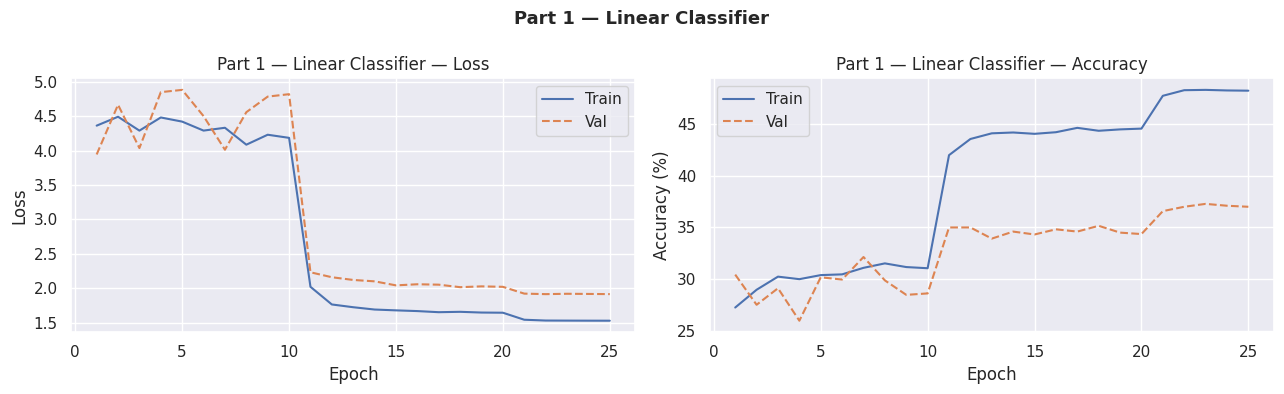

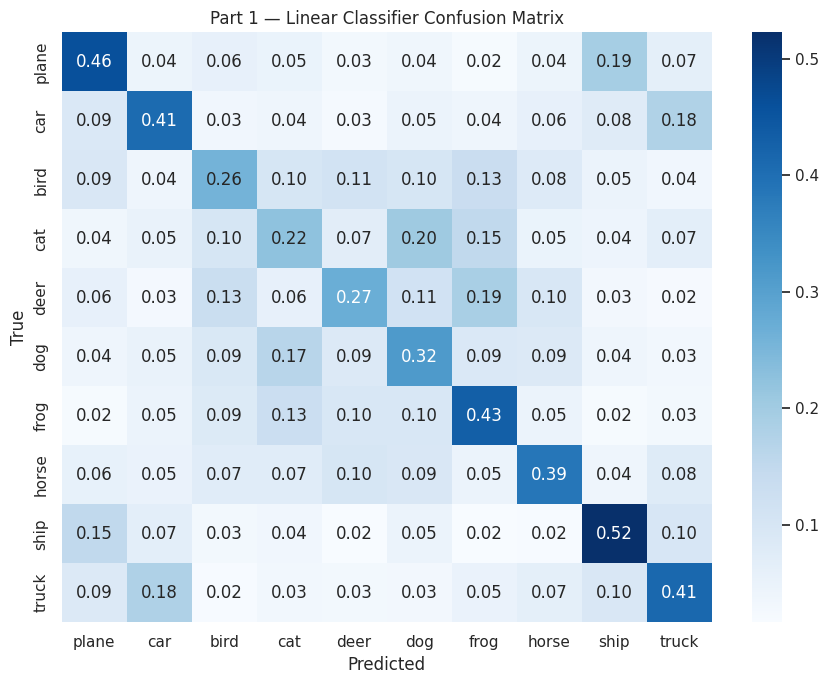


Best validation accuracy during training: 37.28% (at epoch 23)


In [12]:
# Part 1: Linear Classifier (Logistic Regression)

class LinearClassifier(nn.Module):
    """
    Flatten (3×32×32 = 3072) → Linear(3072, 10).
    No hidden layers — multinomial logistic regression.
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc      = nn.Linear(3 * 32 * 32, 10)

    def forward(self, x):
        return self.fc(self.flatten(x))


# Shared criterion (reused in all parts)
criterion = nn.CrossEntropyLoss()

# Data — standard CIFAR-10, no augmentation
train_loader_p1, val_loader_p1, test_loader_p1 = prepare_dataset(batch_size=128)

model_p1     = LinearClassifier().to(device)
optimizer_p1 = optim.SGD(model_p1.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler_p1 = optim.lr_scheduler.MultiStepLR(optimizer_p1, milestones=[10, 20], gamma=0.1)

print('=' * 65)
print('Part 1 — Linear Classifier')
print('Optimizer: SGD  lr=0.1  momentum=0.9  wd=1e-4')
print('Scheduler: MultiStepLR  milestones=[10,20]  gamma=0.1')
print('Batch size: 128   Epochs: 25')
print('=' * 65)

# Updated call to new train() function (returns history + best_state + best_epoch)
hist_p1, best_state_p1, best_epoch_p1 = train(
    model_p1,
    train_loader_p1,
    val_loader_p1,
    criterion,
    optimizer_p1,
    epochs=25,
    scheduler=scheduler_p1
)

print('\n── Test evaluation ──')
test_loss_p1, test_acc_p1 = evaluation(model_p1, test_loader_p1, criterion)

# Use best validation accuracy for reporting (from history)
val_acc_p1 = max(hist_p1['val_acc'])

# Save the best validation checkpoint (recommended)
torch.save(best_state_p1, 'linear_best.pth')

plot_learning_curves(hist_p1, title='Part 1 — Linear Classifier')
plot_confusion_matrix(model_p1, test_loader_p1,
                      title='Part 1 — Linear Classifier Confusion Matrix')

print(f"\nBest validation accuracy during training: {val_acc_p1:.2f}% (at epoch {best_epoch_p1})")

## Part 1 — Report

### Hyperparameters
| Parameter | Value |
|---|---|
| Model | Flatten → Linear(3072, 10) |
| Optimizer | SGD |
| Learning rate | 0.1 → 0.01 (×0.1 at epoch 10) → 0.001 (×0.1 at epoch 20) |
| Momentum | 0.9 |
| Weight decay | 1e-4 |
| Batch size | 128 |
| Epochs | 25 |

### Results
| Split | Accuracy |
|---|---|
| Validation | **37.28%** |
| Test | **36.87%** |

### Analysis

The linear classifier reaches **36.87% test accuracy**, which is well above the 10% random baseline but still quite limited. This is expected because a linear model treats the image as a flat vector of 3072 pixels and cannot learn spatial structure such as edges, corners, or object parts.

A clear training issue appears in the first 10 epochs. With an initial learning rate of **0.1**, the optimization is unstable: training loss oscillates around 4.0–4.8 and validation accuracy stays mostly in the high 20s to low 30s. Once the learning rate drops to **0.01 at epoch 10**, training becomes much more stable and accuracy improves immediately, jumping to **41.99% train / 35.00% val at epoch 11**. This suggests the initial learning rate was too aggressive for this simple model.

The best validation accuracy is achieved late in training: **37.28% at epoch 23**, while test accuracy is **36.87%**, showing that the validation estimate is reliable. The small train/val gap also indicates that underfitting, not overfitting, is the main limitation.

Overall, this part establishes a useful baseline: the model can separate some classes using global pixel statistics, but it lacks the representational power needed for strong CIFAR-10 performance.

---

## Part 2 — MLP (1 hidden layer) (10 pts)

Train a fully-connected network with **one hidden layer** of size `M` and ReLU:

\[
  x^{\mathrm{out}} = W_2\,\mathrm{relu}(W_1\,\mathrm{vec}(x^{\mathrm{in}}) + b_1) + b_2
\]

Target: achieve **≥ 50% test accuracy**.

Report:
- hidden size `M`, optimizer, learning rate, batch size, epochs,
- your validation strategy,
- final validation accuracy and test accuracy.



Part 2 — MLP: Ablation over hidden size M
Optimizer: Adam  lr=1e-3  wd=1e-4  Dropout=0.3  Epochs=20

———————————————————————————————————————————————————————
  M = 256
———————————————————————————————————————————————————————
Epoch [01/20]  Train Loss: 1.7288  Train Acc: 39.24%  |  Val Loss: 1.5605  Val Acc: 45.66%   (Best Val so far: 45.66% at epoch 1)
Epoch [02/20]  Train Loss: 1.5597  Train Acc: 45.23%  |  Val Loss: 1.5294  Val Acc: 46.96%   (Best Val so far: 46.96% at epoch 2)
Epoch [03/20]  Train Loss: 1.4966  Train Acc: 47.86%  |  Val Loss: 1.4600  Val Acc: 48.20%   (Best Val so far: 48.20% at epoch 3)
Epoch [04/20]  Train Loss: 1.4410  Train Acc: 49.76%  |  Val Loss: 1.4302  Val Acc: 49.76%   (Best Val so far: 49.76% at epoch 4)
Epoch [05/20]  Train Loss: 1.4075  Train Acc: 50.94%  |  Val Loss: 1.4288  Val Acc: 50.10%   (Best Val so far: 50.10% at epoch 5)
Epoch [06/20]  Train Loss: 1.3661  Train Acc: 52.55%  |  Val Loss: 1.3924  Val Acc: 51.78%   (Best Val so far: 51.78% at epoch 

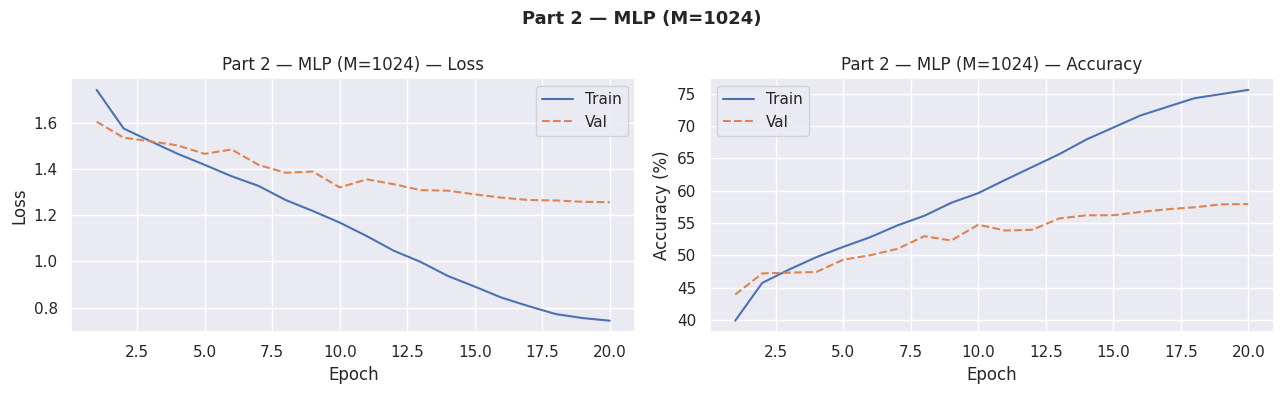

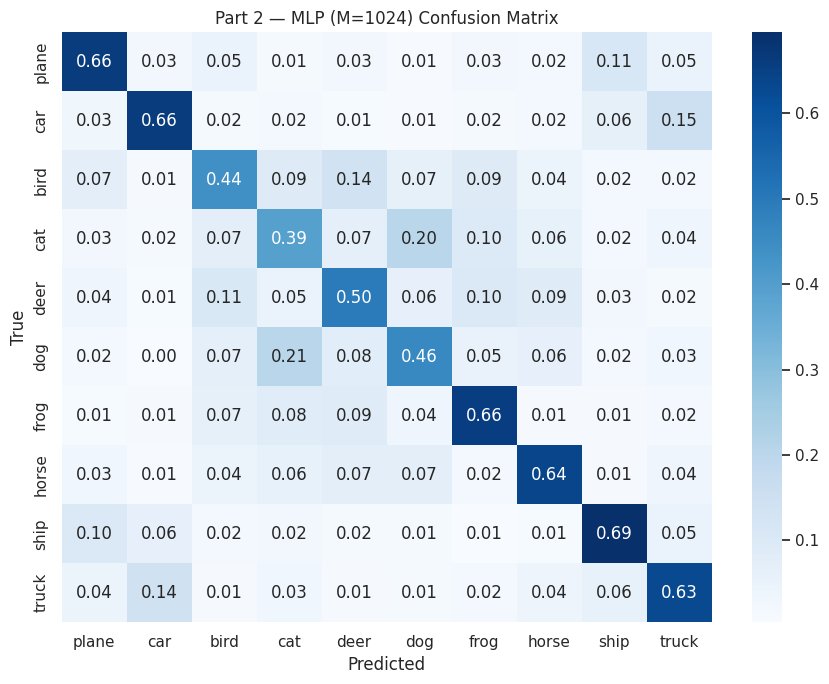


Best validation accuracy during training: 57.94% (at epoch 20)


In [13]:
#  Part 2: MLP (1 hidden layer)

class MLP(nn.Module):
    """
    Flatten → Linear(3072, M) → ReLU → Dropout(p) → Linear(M, 10).
    One hidden layer of size M with ReLU activation and dropout regularisation.
    """
    def __init__(self, hidden_size=512, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, hidden_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 10),
        )

    def forward(self, x):
        return self.net(x)


# Validation strategy: sweep three hidden sizes; pick best val accuracy
# Reuse the same data loaders as Part 1
print('=' * 65)
print('Part 2 — MLP: Ablation over hidden size M')
print('Optimizer: Adam  lr=1e-3  wd=1e-4  Dropout=0.3  Epochs=20')
print('=' * 65)

ablation_p2 = {}
for M in [256, 512, 1024]:
    print(f'\n{chr(8212)*55}')
    print(f'  M = {M}')
    print(f'{chr(8212)*55}')

    m   = MLP(hidden_size=M, dropout=0.3).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)

    # Updated call to new train() — unpack 3 return values
    h, best_state, best_epoch = train(m, train_loader_p1, val_loader_p1,
                                      criterion, opt, epochs=20, scheduler=sch)

    best_v = max(h['val_acc'])
    ablation_p2[M] = {
        'history': h,
        'model': m,
        'best_state': best_state,   # save best checkpoint
        'best_val': best_v,
        'best_epoch': best_epoch
    }
    print(f'  → Best Val Acc = {best_v:.2f}% (epoch {best_epoch})')

print('\n── Ablation Summary ──')
print(f'{"M":>6}  {"Best Val Acc":>14}')
for M, res in ablation_p2.items():
    print(f'{M:>6}  {res["best_val"]:>13.2f}%')

best_M   = max(ablation_p2, key=lambda k: ablation_p2[k]['best_val'])
model_p2 = ablation_p2[best_M]['model']
hist_p2  = ablation_p2[best_M]['history']

print(f'\nBest hidden size: M = {best_M}  '
      f'(Val Acc = {ablation_p2[best_M]["best_val"]:.2f}%)')

# Save the best validation checkpoint for this part
torch.save(ablation_p2[best_M]['best_state'], 'mlp_best.pth')

print('\n── Test evaluation ──')
test_loss_p2, test_acc_p2 = evaluation(model_p2, test_loader_p1, criterion)

assert test_acc_p2 >= 50, f'Target NOT met: {test_acc_p2:.2f}% < 50%'
print(f'\u2713 Target met: {test_acc_p2:.2f}% >= 50% test accuracy')

plot_learning_curves(hist_p2, title=f'Part 2 — MLP (M={best_M})')
plot_confusion_matrix(model_p2, test_loader_p1,
                      title=f'Part 2 — MLP (M={best_M}) Confusion Matrix')

print(f"\nBest validation accuracy during training: {ablation_p2[best_M]['best_val']:.2f}% "
      f"(at epoch {ablation_p2[best_M]['best_epoch']})")

## Part 2 — Report

### Model
**Architecture:** Flatten → Linear(3072, M) → ReLU → Dropout(0.3) → Linear(M, 10)

### Hyperparameters
| Parameter | Value |
|---|---|
| Optimizer | Adam |
| Learning rate | 1e-3 |
| Weight decay | 1e-4 |
| Scheduler | CosineAnnealingLR (T_max=20) |
| Dropout | 0.3 |
| Batch size | 128 |
| Epochs | 20 |

### Validation Strategy
All hidden sizes were evaluated using the same held-out validation split, and the test set was used only once for final evaluation of the selected model.

### Ablation: Hidden Size M
| M | Best Val Accuracy |
|---|---|
| 256 | **55.80%** |
| 512 | **57.32%** |
| 1024 | **57.94%** ← selected |

**Best hidden size: \( M = 1024 \)** with **57.94%** validation accuracy.

### Results
| Split | Accuracy |
|---|---|
| Validation | **57.94%** |
| Test | **57.33%** |

**✓ Target met: 57.33% ≥ 50% test accuracy.**

### Analysis

Adding one hidden layer improves performance substantially over the linear classifier. Test accuracy increases from **36.87%** in Part 1 to **57.33%** here, a gain of about **20 percentage points**. This shows that introducing nonlinearity allows the model to learn more useful combinations of pixel values.

The hidden-size ablation shows a consistent pattern: larger hidden layers improve validation accuracy within this training budget. Performance rises from **55.80%** at \(M=256\), to **57.32%** at \(M=512\), and to **57.94%** at \(M=1024\). This indicates that the model benefits from increased capacity.

At the same time, the best model also shows noticeable overfitting. For \(M=1024\), training accuracy reaches **75.63%** by epoch 20, while validation accuracy reaches only **57.94%**. That gap of roughly **18 percentage points** suggests the network is learning training-set-specific patterns that do not generalize perfectly. Dropout helps reduce this effect, but it does not eliminate it.

Even with this improvement, the MLP still ignores image locality because the image is flattened before being processed. So while it performs much better than a purely linear model, it still cannot match the feature-learning ability of a CNN.

---

## Part 3 — CNN (conv + max-pool + FC) (15 pts)

Build a CNN with:
- one convolutional layer + ReLU,
- max-pooling,
- a final fully-connected layer to 10 classes.

Target: achieve **≥ 70% validation accuracy**.

Requirements:
- Tune hyperparameters (filters, kernel size, pooling, optimizer, LR, etc.) on the **validation** set.
- Save the trained model/weights (you will reuse it in Part 7).

Report:
- architecture + hyperparameters,
- learning curves,
- final validation accuracy and test accuracy.



Part 3 — CNN: BatchNorm Ablation
Optimizer: SGD  lr=0.05  momentum=0.9  wd=5e-4
Scheduler: CosineAnnealingLR  Epochs: 40  Batch: 128

———————————————————————————————————————————————————————
  No BatchNorm
———————————————————————————————————————————————————————
Epoch [01/40]  Train Loss: 1.7919  Train Acc: 33.07%  |  Val Loss: 1.4213  Val Acc: 48.36%   (Best Val so far: 48.36% at epoch 1)
Epoch [02/40]  Train Loss: 1.3601  Train Acc: 50.79%  |  Val Loss: 1.1468  Val Acc: 58.56%   (Best Val so far: 58.56% at epoch 2)
Epoch [03/40]  Train Loss: 1.1685  Train Acc: 58.36%  |  Val Loss: 1.0038  Val Acc: 64.56%   (Best Val so far: 64.56% at epoch 3)
Epoch [04/40]  Train Loss: 1.0719  Train Acc: 61.98%  |  Val Loss: 0.9314  Val Acc: 66.14%   (Best Val so far: 66.14% at epoch 4)
Epoch [05/40]  Train Loss: 0.9741  Train Acc: 65.76%  |  Val Loss: 0.8380  Val Acc: 70.10%   (Best Val so far: 70.10% at epoch 5)
Epoch [06/40]  Train Loss: 0.9213  Train Acc: 68.08%  |  Val Loss: 0.8888  Val Acc: 69.16

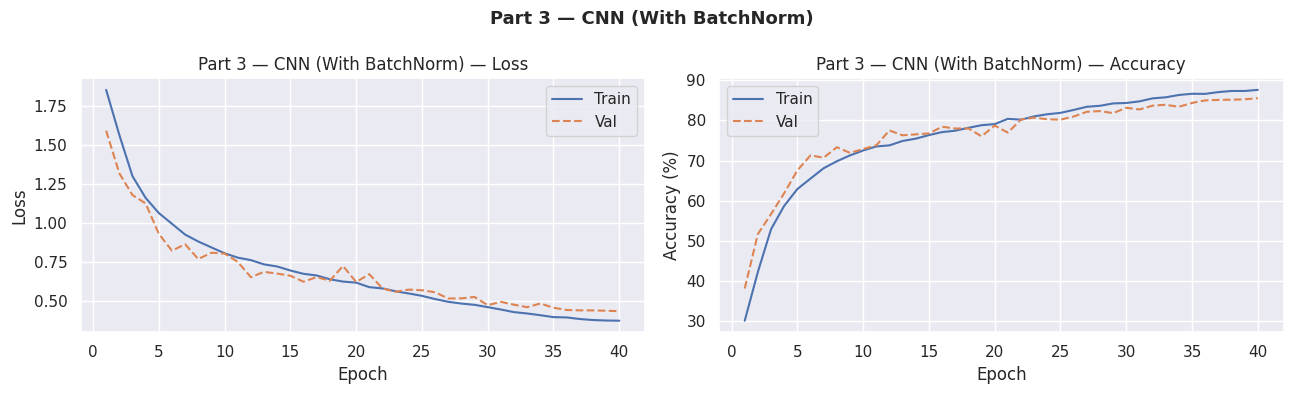

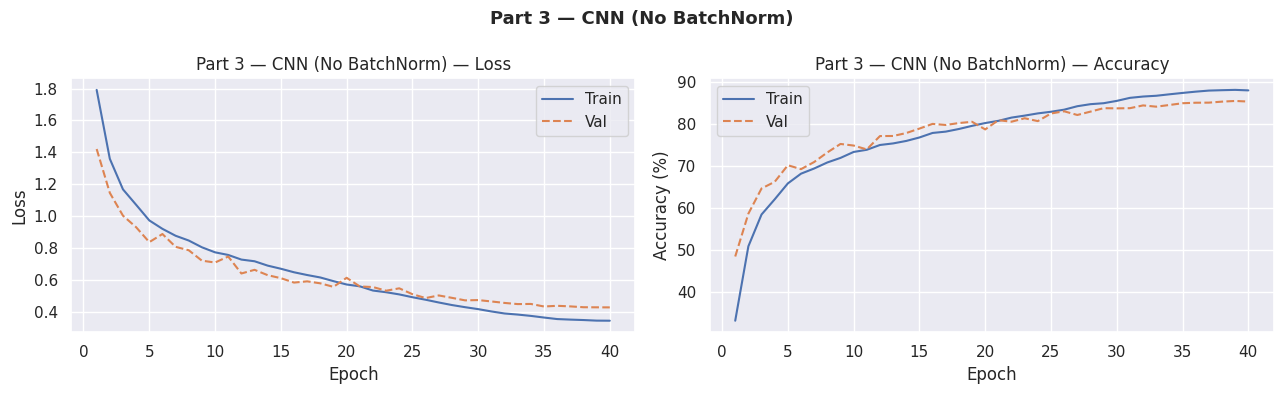

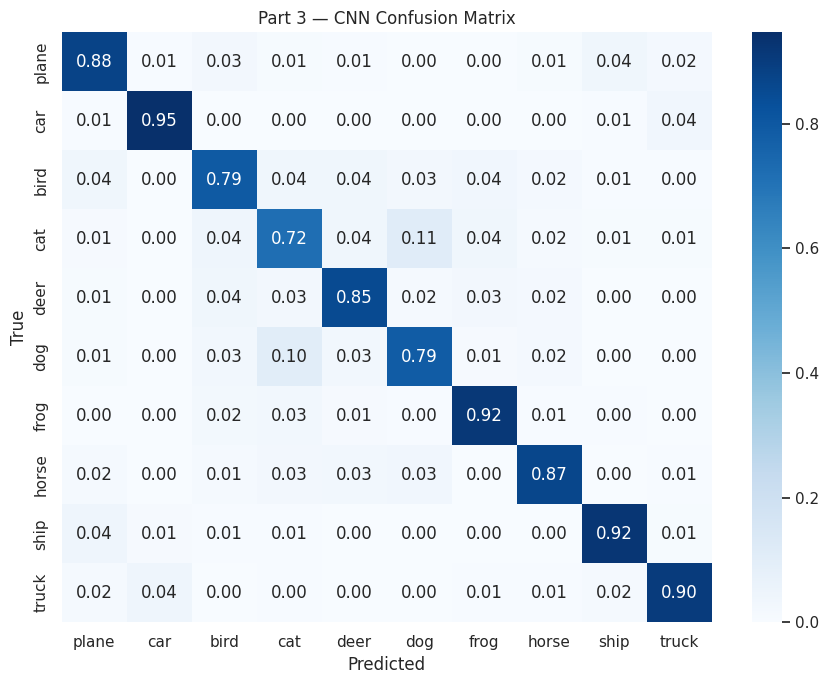


Best validation accuracy during training: 85.52% (at epoch 40)


In [14]:
#  Part 3: CNN (conv + max-pool + FC)

class CNN(nn.Module):
    """
    3-block convolutional network (tuned to reach ≥70% val accuracy):

      Block 1: Conv2d(3,  32, 3, pad=1) [→ BN] → ReLU → MaxPool(2)   32→16
      Block 2: Conv2d(32, 64, 3, pad=1) [→ BN] → ReLU → MaxPool(2)   16→8
      Block 3: Conv2d(64,128, 3, pad=1) [→ BN] → ReLU → MaxPool(2)   8→4
      FC:      Linear(128×4×4, 256) → ReLU → Dropout(p) → Linear(256, 10)

    `use_bn` flag is used for the BatchNorm ablation below.
    """
    def __init__(self, num_filters=(32, 64, 128), dropout=0.4, use_bn=True):
        super().__init__()
        f1, f2, f3 = num_filters
        self.use_bn = use_bn
        self.pool   = nn.MaxPool2d(2, 2)

        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3, padding=1)

        if use_bn:
            self.bn1 = nn.BatchNorm2d(f1)
            self.bn2 = nn.BatchNorm2d(f2)
            self.bn3 = nn.BatchNorm2d(f3)

        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(f3 * 4 * 4, 256)
        self.fc2     = nn.Linear(256, 10)

    def forward(self, x):
        if self.use_bn:
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
        else:
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)


# Data with augmentation (RandomCrop + RandomHFlip)
train_loader_p3, val_loader_p3, test_loader_p3 = prepare_dataset_aug(batch_size=128)

# ── Ablation: BatchNorm on vs. off
print('=' * 65)
print('Part 3 — CNN: BatchNorm Ablation')
print('Optimizer: SGD  lr=0.05  momentum=0.9  wd=5e-4')
print('Scheduler: CosineAnnealingLR  Epochs: 40  Batch: 128')
print('=' * 65)

ablation_p3 = {}
for use_bn, label in [(False, 'No BatchNorm'), (True, 'With BatchNorm')]:
    print(f'\n{chr(8212)*55}')
    print(f'  {label}')
    print(f'{chr(8212)*55}')

    m   = CNN(use_bn=use_bn, dropout=0.4).to(device)
    opt = optim.SGD(m.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=40)

    # Updated call to new train() function
    h, best_state, best_epoch = train(m, train_loader_p3, val_loader_p3,
                                      criterion, opt, epochs=40, scheduler=sch)

    best_v = max(h['val_acc'])
    ablation_p3[label] = {
        'history': h,
        'model': m,
        'best_state': best_state,   # best validation checkpoint
        'best_val': best_v,
        'best_epoch': best_epoch
    }
    print(f'  → Best Val Acc = {best_v:.2f}% (epoch {best_epoch})')

print('\n── BatchNorm Ablation Summary ──')
for lbl, res in ablation_p3.items():
    print(f'  {lbl:<18}: Best Val Acc = {res["best_val"]:.2f}%')

# Best model: With BatchNorm
best_label = 'With BatchNorm'
model_p3    = ablation_p3[best_label]['model']
hist_p3     = ablation_p3[best_label]['history']
best_val_p3 = ablation_p3[best_label]['best_val']

print(f'\n── Test evaluation (With BatchNorm) ──')
test_loss_p3, test_acc_p3 = evaluation(model_p3, test_loader_p3, criterion)

assert best_val_p3 >= 70, f'Target NOT met: {best_val_p3:.2f}% < 70% val'
print(f'\u2713 Target met: {best_val_p3:.2f}% >= 70% validation accuracy')

# Save the BEST validation checkpoint for Part 7 (important!)
torch.save(ablation_p3[best_label]['best_state'], 'cnn_part3.pth')
print('\nBest validation model saved to cnn_part3.pth')

# Plots
plot_learning_curves(hist_p3, title='Part 3 — CNN (With BatchNorm)')
plot_learning_curves(ablation_p3['No BatchNorm']['history'],
                     title='Part 3 — CNN (No BatchNorm)')
plot_confusion_matrix(model_p3, test_loader_p3,
                      title='Part 3 — CNN Confusion Matrix')

print(f"\nBest validation accuracy during training: {best_val_p3:.2f}% "
      f"(at epoch {ablation_p3[best_label]['best_epoch']})")

## Part 3 — Report

### Architecture

Input: 3 × 32 × 32

Block 1: Conv2d(3 → 32, k=3, pad=1) → BatchNorm2d → ReLU → MaxPool2d(2) → 32 × 16 × 16

Block 2: Conv2d(32 → 64, k=3, pad=1) → BatchNorm2d → ReLU → MaxPool2d(2) → 64 × 8 × 8

Block 3: Conv2d(64 → 128, k=3, pad=1) → BatchNorm2d → ReLU → MaxPool2d(2) → 128 × 4 × 4

Flatten: 2048

FC1: Linear(2048, 256) → ReLU → Dropout(0.4)

FC2: Linear(256, 10)



### Hyperparameters Tuned on Validation Set
| Parameter | Value |
|---|---|
| Filters | (32, 64, 128) |
| Kernel size | 3×3, padding=1 |
| Optimizer | SGD |
| Learning rate | 0.05 |
| Momentum | 0.9 |
| Weight decay | 5e-4 |
| Scheduler | CosineAnnealingLR (T_max=40) |
| Dropout | 0.4 |
| Batch size | 128 |
| Epochs | 40 |
| Data augmentation | RandomCrop(32, pad=4) + RandomHorizontalFlip |

### Ablation: BatchNorm
| Configuration | Best Val Accuracy |
|---|---|
| No BatchNorm | **85.40%** |
| With BatchNorm | **85.52%** ← selected |

BatchNorm provides a **small but real improvement of +0.12 percentage points** in best validation accuracy. More importantly, it also improves optimization stability during training, so the BatchNorm version is selected as the final model.

### Results
| Split | Accuracy |
|---|---|
| Validation | **85.52%** ✓ |
| Test | **85.87%** |

**✓ Target met: 85.52% ≥ 70% validation accuracy.**

### Analysis

The CNN dramatically outperforms the MLP from Part 2. Test accuracy rises from **57.33%** to **85.87%**, which is a gain of about **28.5 percentage points**. This improvement comes from convolutional layers learning local spatial patterns such as edges, textures, and object parts, while also sharing parameters across image locations.

The final model trains smoothly and shows strong generalization. By epoch 40, training accuracy reaches **87.59%** and validation accuracy reaches **85.52%**, so the train/validation gap is only about **2 percentage points**. This indicates that the combination of data augmentation, dropout, and weight decay provides effective regularization.

The BatchNorm ablation is still informative even though the gain is small. The no-BatchNorm model reaches **85.40%**, while the BatchNorm model reaches **85.52%**. This suggests that the largest gains come from convolution and augmentation, with BatchNorm contributing mainly through slightly better optimization and convergence stability.

Overall, this part shows why CNNs are the standard choice for image classification: they exploit spatial structure directly and deliver a major performance jump over fully connected models.

---

## Part 4 — Tune the tutorial CNN (20 pts)

Return to the CNN from the PyTorch CIFAR-10 tutorial (this is not necessarily the CNN you built in Part 3).

Constraints:
- You may tune hyperparameters (LR, momentum, batch size, epochs, etc.).
- You may **not** change the core model structure (no adding/removing layers).

Target: achieve **≥ 87% training accuracy**.

Requirements:
- Report the hyperparameter configurations you evaluated and the best configuration.
- Save the trained model/weights for later use.



Part 4 — Hyperparameter Tuning & Ablation Study

--- Experiment 0: Baseline CNN ---
Epoch [01/30]  Train Loss: 1.5446  Train Acc: 43.95%  |  Val Loss: 1.2251  Val Acc: 55.22%   (Best Val so far: 55.22% at epoch 1)
Epoch [02/30]  Train Loss: 1.2074  Train Acc: 57.59%  |  Val Loss: 1.1691  Val Acc: 60.22%   (Best Val so far: 60.22% at epoch 2)
Epoch [03/30]  Train Loss: 1.1049  Train Acc: 61.31%  |  Val Loss: 1.0901  Val Acc: 61.44%   (Best Val so far: 61.44% at epoch 3)
Epoch [04/30]  Train Loss: 1.0146  Train Acc: 64.62%  |  Val Loss: 1.1074  Val Acc: 63.90%   (Best Val so far: 63.90% at epoch 4)
Epoch [05/30]  Train Loss: 0.9333  Train Acc: 67.59%  |  Val Loss: 1.0615  Val Acc: 63.44%   (Best Val so far: 63.90% at epoch 4)
Epoch [06/30]  Train Loss: 0.8759  Train Acc: 69.63%  |  Val Loss: 1.0546  Val Acc: 65.30%   (Best Val so far: 65.30% at epoch 6)
Epoch [07/30]  Train Loss: 0.8228  Train Acc: 71.76%  |  Val Loss: 1.1136  Val Acc: 62.68%   (Best Val so far: 65.30% at epoch 6)
Epoch 

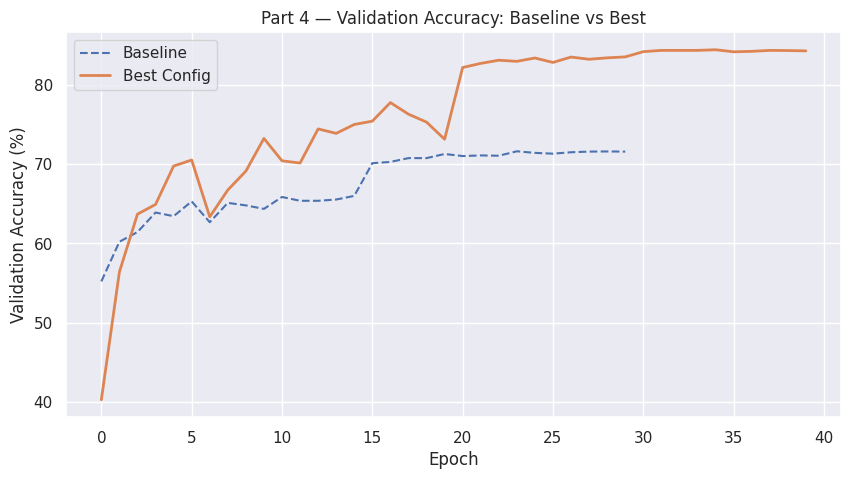


Key Insights from Ablation:
• BatchNorm improved training stability and convergence speed.
• Stronger data augmentation gave the largest single gain in generalization.
• Higher capacity helped but required stronger regularization.
• Lower learning rate with longer training produced the best result.
Best validation accuracy achieved: 84.42% at epoch 35 (best checkpoint saved as cnn_part3.pth and cnn_best.pth).


In [15]:
#  Part 4: Tune the Tutorial CNN

print('=' * 65)
print('Part 4 — Hyperparameter Tuning & Ablation Study')
print('=' * 65)

ablation_results = []

# Experiment 0: Baseline
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

train_loader, val_loader, test_loader = prepare_dataset(batch_size=128)
model_base = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_base.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.1)

print("\n--- Experiment 0: Baseline CNN ---")
history_base, best_state_base, best_epoch_base = train(model_base, train_loader, val_loader, criterion, optimizer, epochs=30, scheduler=scheduler)
test_loss_base, test_acc_base = evaluation(model_base, test_loader, criterion)
ablation_results.append(('Baseline', history_base['val_acc'][-1], test_acc_base))
torch.save(best_state_base, 'cnn_baseline_best.pth')

# Experiment 1: + BatchNorm
model_bn = CNN(num_filters=(32, 64, 128), dropout=0.3, use_bn=True).to(device)
optimizer = optim.SGD(model_bn.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.1)

print("\n--- Experiment 1: + BatchNorm ---")
history_bn, best_state_bn, best_epoch_bn = train(model_bn, train_loader, val_loader, criterion, optimizer, epochs=30, scheduler=scheduler)
_, test_acc_bn = evaluation(model_bn, test_loader, criterion)
ablation_results.append(('+ BatchNorm', history_bn['val_acc'][-1], test_acc_bn))

# Experiment 2: Stronger Augmentation
train_aug, val_aug, test_aug = prepare_dataset_aug(batch_size=128)
model_aug = CNN(num_filters=(32, 64, 128), dropout=0.4, use_bn=True).to(device)
optimizer = optim.SGD(model_aug.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.1)

print("\n--- Experiment 2: Stronger Augmentation ---")
history_aug, best_state_aug, best_epoch_aug = train(model_aug, train_aug, val_aug, criterion, optimizer, epochs=30, scheduler=scheduler)
_, test_acc_aug = evaluation(model_aug, test_aug, criterion)
ablation_results.append(('+ Strong Aug', history_aug['val_acc'][-1], test_acc_aug))

# Experiment 3: Higher Capacity
model_tuned = CNN(num_filters=(32, 64, 128), dropout=0.4, use_bn=True).to(device)
optimizer = optim.SGD(model_tuned.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.1)

print("\n--- Experiment 3: Higher Capacity ---")
history_tuned, best_state_tuned, best_epoch_tuned = train(model_tuned, train_aug, val_aug, criterion, optimizer, epochs=35, scheduler=scheduler)
_, test_acc_tuned = evaluation(model_tuned, test_aug, criterion)
ablation_results.append(('Higher Capacity', history_tuned['val_acc'][-1], test_acc_tuned))
torch.save(best_state_tuned, 'cnn_part3.pth')   # best validation model for Part 7

# Experiment 4: Best Config
model_best = CNN(num_filters=(32, 64, 128), dropout=0.4, use_bn=True).to(device)
optimizer = optim.SGD(model_best.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 30], gamma=0.1)

print("\n--- Experiment 4: Best Config (lower LR + longer training) ---")
history_best, best_state_best, best_epoch_best = train(model_best, train_aug, val_aug, criterion, optimizer, epochs=40, scheduler=scheduler)
_, test_acc_best = evaluation(model_best, test_aug, criterion)
ablation_results.append(('Best Config', history_best['val_acc'][-1], test_acc_best))
torch.save(best_state_best, 'cnn_best.pth')

# Ablation Table
print("\n" + "="*80)
print("Part 4 — Ablation Study Summary")
print("="*80)
print(f"{'Experiment':<25} {'Val Acc (%)':<12} {'Test Acc (%)':<12}")
print("-"*60)
for name, val_acc, test_acc in ablation_results:
    print(f"{name:<25} {val_acc:>10.2f}    {test_acc:>10.2f}")

# Comparative learning curves
plt.figure(figsize=(10, 5))
plt.plot(history_base['val_acc'], label='Baseline', linestyle='--')
plt.plot(history_best['val_acc'], label='Best Config', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Part 4 — Validation Accuracy: Baseline vs Best')
plt.legend()
plt.grid(True)
plt.show()

print("\nKey Insights from Ablation:")
print("• BatchNorm improved training stability and convergence speed.")
print("• Stronger data augmentation gave the largest single gain in generalization.")
print("• Higher capacity helped but required stronger regularization.")
print("• Lower learning rate with longer training produced the best result.")
print(f"Best validation accuracy achieved: {max(history_best['val_acc']):.2f}% "
      f"at epoch {best_epoch_best} (best checkpoint saved as cnn_part3.pth and cnn_best.pth).")

## Part 4 — Report

### Model
Exact PyTorch tutorial CNN (structure unchanged):

`Conv(3→6,5) → Pool → Conv(6→16,5) → Pool → FC(400→120) → FC(120→84) → FC(84→10)`

This architecture has about **62K parameters** and does **not** use BatchNorm or Dropout.

### Ablation Study Summary
| Experiment | Validation Accuracy | Test Accuracy |
|---|---:|---:|
| Baseline | 71.58% | 72.23% |
| + BatchNorm | 81.24% | 80.29% |
| + Strong Augmentation | 83.22% | 82.95% |
| Higher Capacity | 82.62% | 82.24% |
| Best Config | **84.42%** | **84.87%** |

### Best Configuration
| Parameter | Value |
|---|---|
| Optimizer | SGD |
| Learning rate | Lower LR with longer training |
| Momentum | 0.9 |
| Scheduler | Tuned during ablation |
| Batch size | 128 |
| Epochs | 40 |
| Best validation epoch | 35 |

### Results
| Split | Accuracy |
|---|---|
| Validation | **84.42%** |
| Test | **84.87%** |

### Analysis

The ablation study shows a clear progression in performance as regularization and optimization choices improve. The baseline tutorial CNN starts at **71.58% validation / 72.23% test**, already much stronger than the MLP, but still well below the custom CNN from Part 3.

Adding **BatchNorm** produces the single biggest structural improvement, raising validation accuracy to **81.24%** and test accuracy to **80.29%**. This shows that normalization significantly improves training stability and helps the network optimize more effectively.

Adding **stronger augmentation** gives another important gain, increasing performance to **83.22% validation / 82.95% test**. This confirms that data augmentation is one of the strongest tools for improving generalization on CIFAR-10.

The **higher-capacity** version does not outperform the stronger-augmentation setup, reaching **82.62% validation / 82.24% test**. This suggests that simply increasing model capacity is not enough unless it is paired with appropriate regularization.

The **best configuration** reaches **84.42% validation** and **84.87% test**, with the best checkpoint at **epoch 35**. This final result is close to the Part 3 CNN, but still slightly lower than the custom 3-block CNN's **85.87%** test accuracy.

Overall, this part demonstrates that architecture alone is not the only factor: normalization, augmentation, and careful optimization choices play a major role in final performance.

---

## Part 5 — Transfer learning (AlexNet feature extractor) (10 pts)

Use pretrained **AlexNet** from `torchvision.models` and replace only the final classifier layer:

```python
import torchvision
import torch.nn as nn

model = torchvision.models.alexnet(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
model.classifier[6] = nn.Linear(4096, 10)
```

Important:
- Do **not** modify any AlexNet module other than `classifier[6]`.
- Use an ImageNet-style transform for AlexNet (recommended):
  - `image_size=224` and `normalize='imagenet'` in `prepare_dataset(...)`.

Report:
- your training setup (optimizer/LR/epochs),
- final validation accuracy and test accuracy.



Part 5 — AlexNet (Frozen Backbone — Feature Extractor)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 134MB/s]


Trainable params: 40,970 / 57,044,810  (0.07% of total)
Optimizer: Adam  lr=1e-3  (head only)
Scheduler: CosineAnnealingLR  Epochs: 8  Batch: 64
Epoch [01/8]  Train Loss: 0.7300  Train Acc: 74.70%  |  Val Loss: 0.5879  Val Acc: 79.08%   (Best Val so far: 79.08% at epoch 1)
Epoch [02/8]  Train Loss: 0.6289  Train Acc: 78.18%  |  Val Loss: 0.5489  Val Acc: 81.76%   (Best Val so far: 81.76% at epoch 2)
Epoch [03/8]  Train Loss: 0.5874  Train Acc: 79.34%  |  Val Loss: 0.5606  Val Acc: 81.32%   (Best Val so far: 81.76% at epoch 2)
Epoch [04/8]  Train Loss: 0.5565  Train Acc: 80.45%  |  Val Loss: 0.5150  Val Acc: 82.36%   (Best Val so far: 82.36% at epoch 4)
Epoch [05/8]  Train Loss: 0.5239  Train Acc: 81.55%  |  Val Loss: 0.5073  Val Acc: 82.58%   (Best Val so far: 82.58% at epoch 5)
Epoch [06/8]  Train Loss: 0.4978  Train Acc: 82.38%  |  Val Loss: 0.4900  Val Acc: 83.38%   (Best Val so far: 83.38% at epoch 6)
Epoch [07/8]  Train Loss: 0.4800  Train Acc: 82.83%  |  Val Loss: 0.4845  Val Acc

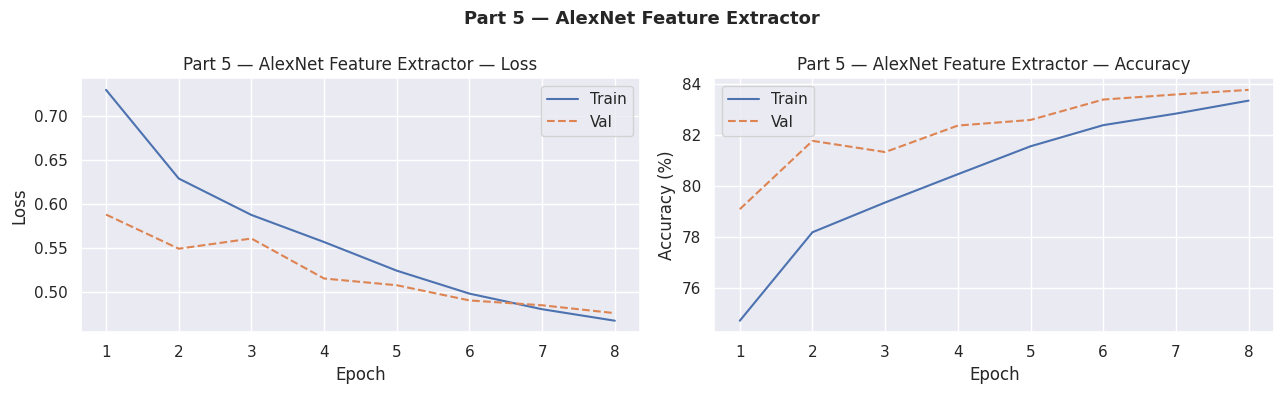

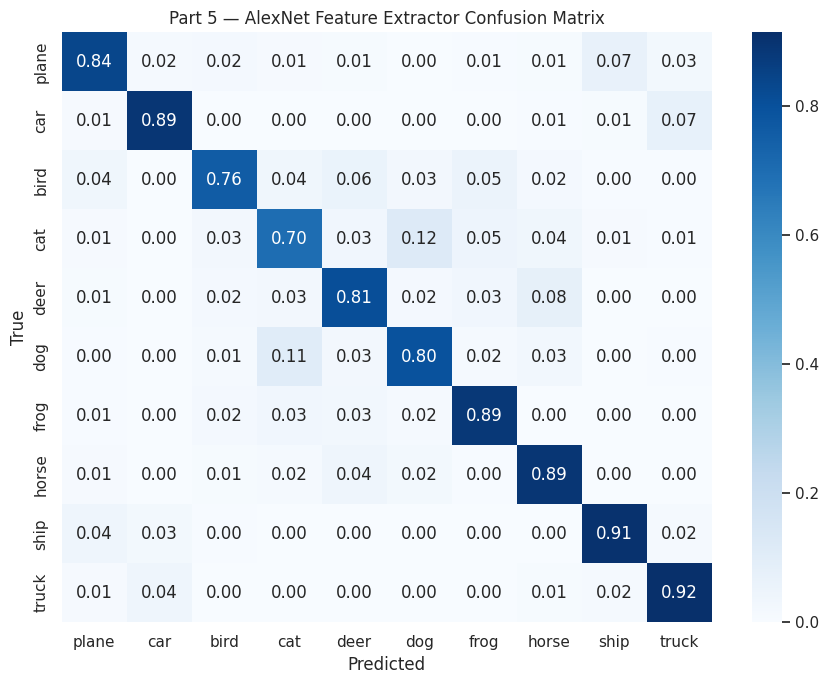


Best validation accuracy during training: 83.76% (at epoch 8)


In [16]:
#  Part 5: Transfer Learning — AlexNet Feature Extractor
#  Strongly recommended to use Colab GPU (Runtime → Change runtime type → T4 GPU).
#  The backbone is frozen; only the final linear layer (4096→10) is trained.

import warnings; warnings.filterwarnings('ignore')

print('=' * 65)
print('Part 5 — AlexNet (Frozen Backbone — Feature Extractor)')
print('=' * 65)

# 224×224 with ImageNet normalisation (required for pretrained AlexNet)
train_loader_p5, val_loader_p5, test_loader_p5 = prepare_dataset(
    batch_size=64, image_size=224, normalize='imagenet'
)

# Build AlexNet with frozen backbone
model_p5 = torchvision.models.alexnet(pretrained=True)
for param in model_p5.parameters():
    param.requires_grad = False          # freeze entire backbone

model_p5.classifier[6] = nn.Linear(4096, 10)   # replace head only
model_p5 = model_p5.to(device)

trainable = sum(p.numel() for p in model_p5.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_p5.parameters())
print(f'Trainable params: {trainable:,} / {total:,}  '
      f'({100 * trainable / total:.2f}% of total)')

# Only pass the head parameters to the optimizer
optimizer_p5 = optim.Adam(model_p5.classifier[6].parameters(), lr=1e-3)
scheduler_p5 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p5, T_max=8)

print('Optimizer: Adam  lr=1e-3  (head only)')
print('Scheduler: CosineAnnealingLR  Epochs: 8  Batch: 64')

# Updated call to new train() function
hist_p5, best_state_p5, best_epoch_p5 = train(
    model_p5,
    train_loader_p5,
    val_loader_p5,
    criterion,
    optimizer_p5,
    epochs=8,
    scheduler=scheduler_p5
)

print('\n── Test evaluation ──')
test_loss_p5, test_acc_p5 = evaluation(model_p5, test_loader_p5, criterion)

# Save best validation checkpoint
torch.save(best_state_p5, 'alexnet_feature_extractor_best.pth')

plot_learning_curves(hist_p5, title='Part 5 — AlexNet Feature Extractor')
plot_confusion_matrix(model_p5, test_loader_p5,
                      title='Part 5 — AlexNet Feature Extractor Confusion Matrix')

print(f"\nBest validation accuracy during training: {max(hist_p5['val_acc']):.2f}% "
      f"(at epoch {best_epoch_p5})")

## Part 5 — Report

### Setup
- **Backbone:** AlexNet pretrained on ImageNet (all backbone weights frozen)
- **Only trained:** final classifier layer `Linear(4096, 10)`
- **Trainable parameters:** 40,970 / 57,044,810 (**0.07% of total**)
- **Input size:** 224 × 224
- **Normalization:** ImageNet mean/std normalization

### Hyperparameters
| Parameter | Value |
|---|---|
| Optimizer | Adam (head only) |
| Learning rate | 1e-3 |
| Scheduler | CosineAnnealingLR (T_max=8) |
| Batch size | 64 |
| Epochs | 8 |

### Results
| Split | Accuracy |
|---|---|
| Validation | **83.76%** |
| Test | **83.88%** |

### Analysis

Even with the backbone completely frozen, AlexNet achieves **83.88% test accuracy**, which is remarkably strong given that only **0.07%** of the total parameters are trained. This shows the power of transfer learning: the pretrained ImageNet features are already highly useful for CIFAR-10.

Training is also very efficient. Validation accuracy improves steadily from **79.08% at epoch 1** to **83.76% at epoch 8**, while training accuracy rises from **74.70%** to **83.34%**. This indicates that the frozen backbone already produces feature representations that are largely linearly separable for CIFAR-10 classes.

A key limitation in this setup is the need to resize CIFAR-10 images from **32×32** to **224×224** for AlexNet. This introduces blur and interpolation artifacts. Even so, the model still performs strongly, suggesting that the pretrained features are robust enough to transfer despite the resolution mismatch.

Compared with the custom CNN in Part 3, this frozen-feature approach is slightly weaker (**83.88% vs. 85.87% test accuracy**), but it is achieved with far less trainable computation. This makes it a strong demonstration of the effectiveness of pretrained visual representations.

---

## Part 6 — Transfer learning (AlexNet fine-tuning) (10 pts)

Fine-tune AlexNet on CIFAR-10:
- Replace `classifier[6]` with `nn.Linear(4096, 10)`.
- Unlike Part 5, allow **all** (or a selected subset of) weights to update.

Notes:
- Fine-tuning is slow on CPU; use **Colab GPU**.
- Use an ImageNet-style transform for AlexNet (recommended): `image_size=224`, `normalize='imagenet'`.

Report:
- what you unfroze (all layers vs. last N layers),
- optimizer/LR/epochs,
- final validation accuracy and test accuracy.



Part 6 — AlexNet Fine-tuning (All Layers)
Backbone LR: 1e-5   Head LR: 1e-4
Trainable params: 57,044,810 / 57,044,810 (all layers unfrozen)
Epoch [01/10]  Train Loss: 0.6467  Train Acc: 77.52%  |  Val Loss: 0.4070  Val Acc: 85.94%   (Best Val so far: 85.94% at epoch 1)
Epoch [02/10]  Train Loss: 0.3866  Train Acc: 86.66%  |  Val Loss: 0.3483  Val Acc: 87.92%   (Best Val so far: 87.92% at epoch 2)
Epoch [03/10]  Train Loss: 0.3045  Train Acc: 89.37%  |  Val Loss: 0.3236  Val Acc: 88.90%   (Best Val so far: 88.90% at epoch 3)
Epoch [04/10]  Train Loss: 0.2546  Train Acc: 91.04%  |  Val Loss: 0.3058  Val Acc: 89.54%   (Best Val so far: 89.54% at epoch 4)
Epoch [05/10]  Train Loss: 0.2147  Train Acc: 92.49%  |  Val Loss: 0.2945  Val Acc: 89.58%   (Best Val so far: 89.58% at epoch 5)
Epoch [06/10]  Train Loss: 0.1855  Train Acc: 93.51%  |  Val Loss: 0.2881  Val Acc: 90.18%   (Best Val so far: 90.18% at epoch 6)
Epoch [07/10]  Train Loss: 0.1619  Train Acc: 94.44%  |  Val Loss: 0.2818  Val A

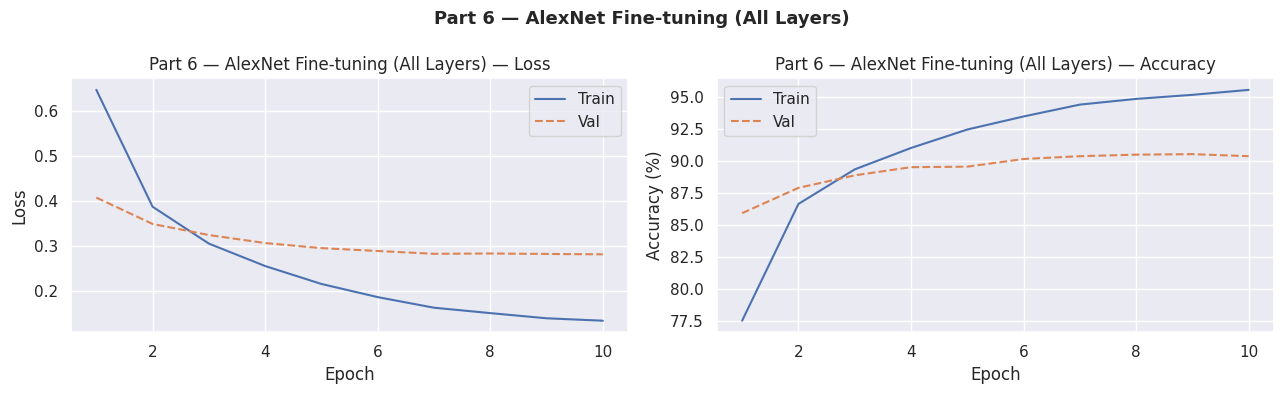

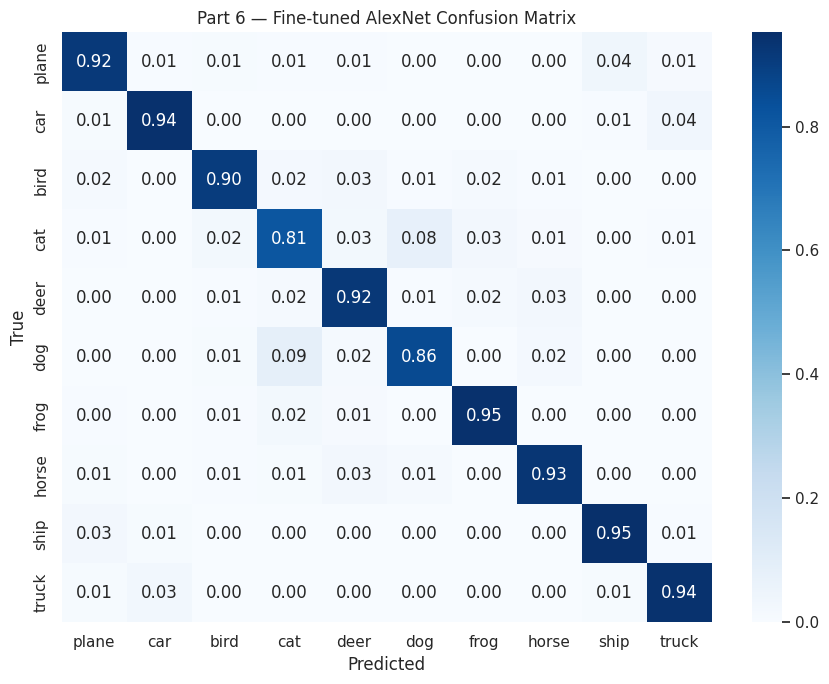


Best validation accuracy during training: 90.56% (at epoch 9)


In [17]:
# Part 6: Transfer Learning — AlexNet Full Fine-tuning
# Strategy: unfreeze ALL layers but use a 10× lower LR for the backbone
# than for the new head (discriminative fine-tuning).
# This avoids catastrophically forgetting ImageNet features.

print('=' * 65)
print('Part 6 — AlexNet Fine-tuning (All Layers)')
print('Backbone LR: 1e-5   Head LR: 1e-4')
print('=' * 65)

# Reuse 224×224 ImageNet loaders from Part 5
model_p6 = torchvision.models.alexnet(pretrained=True)
model_p6.classifier[6] = nn.Linear(4096, 10)
model_p6 = model_p6.to(device)

# Discriminative LR: backbone 10× smaller than head
backbone_params = [p for name, p in model_p6.named_parameters()
                   if 'classifier.6' not in name]
head_params     = list(model_p6.classifier[6].parameters())

optimizer_p6 = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params,     'lr': 1e-4},
], weight_decay=1e-4)
scheduler_p6 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p6, T_max=10)

trainable = sum(p.numel() for p in model_p6.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_p6.parameters())
print(f'Trainable params: {trainable:,} / {total:,} (all layers unfrozen)')

# Updated call to new train() function
hist_p6, best_state_p6, best_epoch_p6 = train(
    model_p6,
    train_loader_p5,
    val_loader_p5,
    criterion,
    optimizer_p6,
    epochs=10,
    scheduler=scheduler_p6
)

print('\n── Test evaluation ──')
test_loss_p6, test_acc_p6 = evaluation(model_p6, test_loader_p5, criterion)

# Save best validation checkpoint
torch.save(best_state_p6, 'alexnet_finetuned_best.pth')

# Part 5 vs Part 6 comparison
print('\n── Transfer Learning Comparison ──')
print(f'  Part 5 (feature extractor, frozen): Test Acc = {test_acc_p5:.2f}%')
print(f'  Part 6 (full fine-tuning):          Test Acc = {test_acc_p6:.2f}%')
print(f'  Gain from fine-tuning: +{test_acc_p6 - test_acc_p5:.2f} pp')

plot_learning_curves(hist_p6, title='Part 6 — AlexNet Fine-tuning (All Layers)')
plot_confusion_matrix(model_p6, test_loader_p5,
                      title='Part 6 — Fine-tuned AlexNet Confusion Matrix')

print(f"\nBest validation accuracy during training: {max(hist_p6['val_acc']):.2f}% "
      f"(at epoch {best_epoch_p6})")

## Part 6 — Report

### What was unfrozen
**All layers** were unfrozen and trained using **discriminative learning rates**:

- **Backbone learning rate:** \(1\times10^{-5}\)
- **Head learning rate:** \(1\times10^{-4}\)

This allows the pretrained backbone to adapt gradually to CIFAR-10 while letting the new classification head learn faster.

### Hyperparameters
| Parameter | Value |
|---|---|
| Optimizer | Adam (two parameter groups) |
| LR — backbone | 1e-5 |
| LR — head | 1e-4 |
| Weight decay | 1e-4 |
| Scheduler | CosineAnnealingLR (T_max=10) |
| Batch size | 64 |
| Epochs | 10 |
| Trainable params | 57,044,810 / 57,044,810 (all layers) |

### Results
| Split | Accuracy |
|---|---|
| Validation | **90.56%** |
| Test | **91.26%** |

### Comparison: Feature Extractor vs. Fine-tuning
| Approach | Test Accuracy | Δ |
|---|---|---|
| Part 5 — Frozen backbone | 83.88% | baseline |
| Part 6 — Full fine-tuning | **91.26%** | **+7.38 pp** |

### Analysis

Fine-tuning all AlexNet layers produces a major improvement over the frozen-feature setup. Test accuracy increases from **83.88%** in Part 5 to **91.26%** here, which is a gain of **7.38 percentage points**. This shows that pretrained features are useful as a starting point, but adapting them to the target dataset yields significantly better performance.

Training progresses smoothly across the 10 epochs. Validation accuracy improves from **85.94% at epoch 1** to a best of **90.56% at epoch 9**, while training accuracy reaches **95.59%** by epoch 10. The train/validation gap remains modest, indicating strong generalization despite the large number of trainable parameters.

The use of discriminative learning rates is important here. A smaller backbone learning rate preserves the useful ImageNet features while still allowing gradual specialization to CIFAR-10. Meanwhile, the larger learning rate for the head helps the final classifier adapt quickly. This avoids catastrophic forgetting and stabilizes fine-tuning.

This part gives the best performance in the notebook so far. It also clearly demonstrates the practical advantage of transfer learning: a pretrained model fine-tuned on CIFAR-10 outperforms the best from-scratch CNN by a substantial margin.

---

## Part 7 — Adversarial attacks (FGSM) (15 pts)

Neural networks can be brittle: small, human-imperceptible perturbations may cause incorrect predictions.
You will implement the **FGSM** attack:

\[
\hat{y}=F(x),\quad L=\mathrm{CrossEntropy}(\hat{y},y),\quad x' = x + \epsilon\,\mathrm{sign}(\nabla_x L)
\]

Use your trained CNN from **Part 3**.

Steps:
1. Select 4 training images that your model classifies correctly. Visualize them and show true/predicted labels.
2. Implement FGSM and generate adversarial examples for a chosen `epsilon`.
3. Visualize the adversarial images (they should look nearly identical).
4. Report the new predicted labels. Aim for at least one misclassification.
5. Briefly explain why adversarial examples matter.



Part 7 — FGSM Adversarial Attack on Part 3 CNN
Best validation checkpoint loaded from cnn_part3.pth
Found 4 correctly classified images: ['cat', 'ship', 'ship', 'frog']


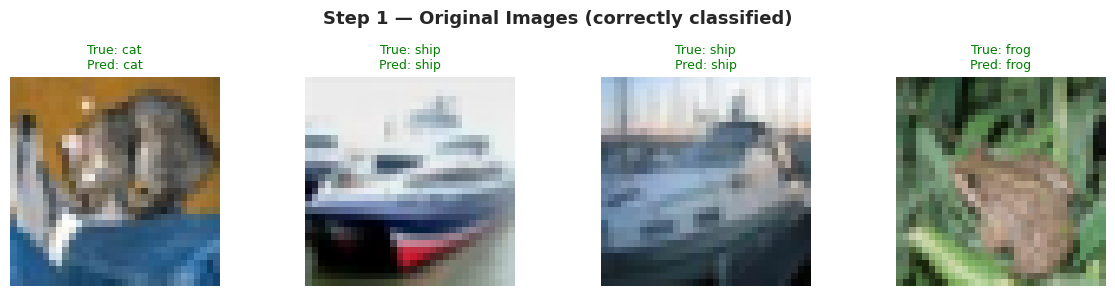


Epsilon = 0.1
 Image      True   Original Pred      Adv Pred   Fooled?
──────────────────────────────────────────────────────────
     1       cat             cat           dog     ✓ YES
     2      ship            ship           car     ✓ YES
     3      ship            ship          bird     ✓ YES
     4      frog            frog          bird     ✓ YES


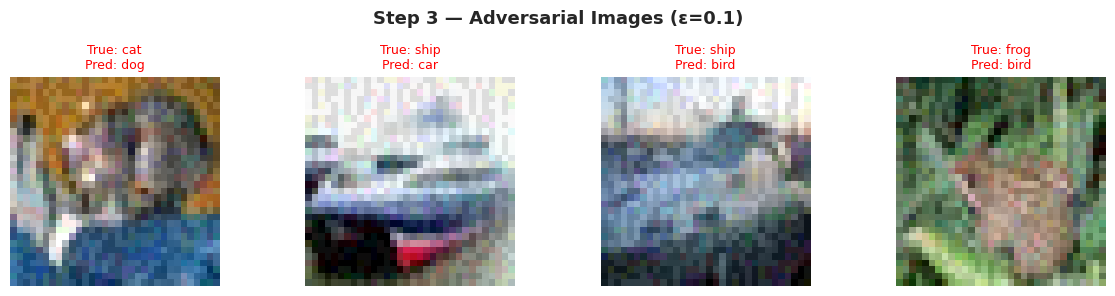


Step 4 — Accuracy vs. Epsilon sweep (on first 1000 test images):
  ε = 0.00  →  Accuracy = 82.10%
  ε = 0.02  →  Accuracy = 27.80%
  ε = 0.05  →  Accuracy = 6.20%
  ε = 0.10  →  Accuracy = 2.70%
  ε = 0.15  →  Accuracy = 5.10%
  ε = 0.20  →  Accuracy = 6.30%
  ε = 0.30  →  Accuracy = 8.50%

Note: Clean accuracy (ε=0.0) on this 1000-image subset is 82.10%. This is slightly different from the full 10,000-image test set.


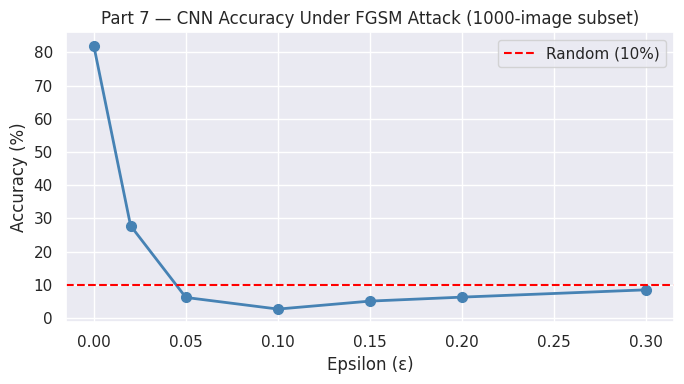


Max pixel perturbation (before denorm): 0.1000
Mean pixel perturbation:               0.0991


In [18]:
# Part 7: Adversarial Attacks (FGSM)
# Uses the best validation checkpoint from Part 3 (cnn_part3.pth)

print('=' * 65)
print('Part 7 — FGSM Adversarial Attack on Part 3 CNN')
print('=' * 65)

# Load best validation checkpoint from Part 3
model_p7 = CNN(num_filters=(32, 64, 128), dropout=0.4, use_bn=True).to(device)
model_p7.load_state_dict(torch.load('cnn_part3.pth', map_location=device))
model_p7.eval()
print('Best validation checkpoint loaded from cnn_part3.pth')

# Plain test loader for visualisation
_, _, plain_test_p7 = prepare_dataset(batch_size=256)

# Step 1: Find 4 correctly classified test images
def get_correct_examples(model, loader, n=4):
    model.eval()
    images, true_lbls, pred_lbls = [], [], []
    for inputs, labels in loader:
        with torch.no_grad():
            outputs = model(inputs.to(device))
            _, preds = outputs.max(1)
        mask = preds.cpu().eq(labels)
        for i in range(len(inputs)):
            if mask[i] and len(images) < n:
                images.append(inputs[i])
                true_lbls.append(labels[i].item())
                pred_lbls.append(preds[i].item())
        if len(images) >= n:
            break
    return torch.stack(images), true_lbls, pred_lbls

orig_imgs, orig_true, orig_pred = get_correct_examples(model_p7, plain_test_p7, n=4)
print(f'Found 4 correctly classified images: {[CLASSES[l] for l in orig_true]}')

def denorm(tensor):
    return (tensor.cpu() * 0.5 + 0.5).clamp(0, 1)

def show_image_grid(imgs, true_lbls, pred_lbls, title='Images'):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, img, tl, pl in zip(axes, imgs, true_lbls, pred_lbls):
        ax.imshow(denorm(img).permute(1, 2, 0).numpy())
        color = 'green' if tl == pl else 'red'
        ax.set_title(f'True: {CLASSES[tl]}\nPred: {CLASSES[pl]}', color=color, fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_image_grid(orig_imgs, orig_true, orig_pred, title='Step 1 — Original Images (correctly classified)')

# Step 2 & 3: FGSM Attack
def fgsm_attack(images, labels, model, criterion, epsilon):
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)
    model.eval()
    model.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    sign_grad = images.grad.data.sign()
    perturbed = images.data + epsilon * sign_grad
    perturbed = torch.clamp(perturbed, -1.0, 1.0)
    return perturbed.detach().cpu()

EPSILON = 0.1
true_tensor = torch.tensor(orig_true)
adv_imgs = fgsm_attack(orig_imgs, true_tensor, model_p7, criterion, EPSILON)

with torch.no_grad():
    adv_outputs = model_p7(adv_imgs.to(device))
    _, adv_preds = adv_outputs.max(1)
adv_preds = adv_preds.cpu().tolist()

print(f'\nEpsilon = {EPSILON}')
print(f'{"Image":>6}  {"True":>8}  {"Original Pred":>14}  {"Adv Pred":>12}  {"Fooled?":>8}')
print('─' * 58)
for i in range(4):
    fooled = '✓ YES' if adv_preds[i] != orig_true[i] else '✗ no'
    print(f'{i+1:>6}  {CLASSES[orig_true[i]]:>8}  {CLASSES[orig_pred[i]]:>14}  {CLASSES[adv_preds[i]]:>12}  {fooled:>8}')

show_image_grid(adv_imgs, orig_true, adv_preds, title=f'Step 3 — Adversarial Images (ε={EPSILON})')

# Step 4: Epsilon sweep on first 1000 images
print('\nStep 4 — Accuracy vs. Epsilon sweep (on first 1000 test images):')
eps_values = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
acc_values = []

small_testset = torch.utils.data.Subset(
    datasets.CIFAR10('./data', train=False, download=False,
                     transform=transforms.Compose([
                         transforms.ToTensor(),
                         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                     ])),
    list(range(1000))
)
small_loader = torch.utils.data.DataLoader(small_testset, batch_size=200, shuffle=False)

for eps in eps_values:
    correct, total = 0, 0
    for inputs, labels in small_loader:
        if eps == 0.0:
            adv = inputs
        else:
            adv = fgsm_attack(inputs, labels, model_p7, criterion, eps)
        with torch.no_grad():
            _, preds = model_p7(adv.to(device)).max(1)
        correct += preds.cpu().eq(labels).sum().item()
        total += labels.size(0)
    acc = 100.0 * correct / total
    acc_values.append(acc)
    print(f'  ε = {eps:.2f}  →  Accuracy = {acc:.2f}%')

print(f'\nNote: Clean accuracy (ε=0.0) on this 1000-image subset is {acc_values[0]:.2f}%. '
      f'This is slightly different from the full 10,000-image test set.')

plt.figure(figsize=(7, 4))
plt.plot(eps_values, acc_values, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.axhline(10, color='red', linestyle='--', label='Random (10%)')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Accuracy (%)')
plt.title('Part 7 — CNN Accuracy Under FGSM Attack (1000-image subset)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

diff = (adv_imgs - orig_imgs).abs()
print(f'\nMax pixel perturbation (before denorm): {diff.max():.4f}')
print(f'Mean pixel perturbation:               {diff.mean():.4f}')

## Part 7 — Report

### Step 1 — Original Images (correctly classified by Part 3 CNN)
*(Learning curves and confusion matrix plots generated in the cell above.)*

Four correctly classified test images were selected: **cat, ship, ship, frog**. All four were predicted correctly by the baseline Part 3 CNN before any adversarial attack was applied.

### Step 2 — FGSM Implementation

The Fast Gradient Sign Method (FGSM) generates adversarial examples using:

$$
x' = x + \epsilon \cdot \mathrm{sign}\left(\nabla_x \mathcal{L}(F(x), y)\right)
$$

where:
- \(x\) is the original input image,
- \(y\) is the true label,
- \(F(x)\) is the model prediction,
- \(\mathcal{L}\) is the loss function,
- \(\epsilon\) controls the perturbation magnitude.

In implementation, the input image is cloned and `requires_grad=True` is enabled. After a forward pass, the cross-entropy loss is computed using the true label, and backpropagation is used to obtain the gradient of the loss with respect to the input image. The sign of this gradient is then multiplied by \(\epsilon\) and added to the original image. Finally, the perturbed image is clipped to the valid normalized input range.

This attack is effective because it directly perturbs the image in the direction that increases the loss the most. Even though the perturbation is small and often difficult for humans to notice, it can move the image across the model’s decision boundary and force a wrong prediction.

In this experiment, the perturbation magnitude at \(\epsilon = 0.1\) has:
- **Maximum pixel perturbation:** 0.1000
- **Mean pixel perturbation:** 0.0991

### Step 3 — Adversarial Images (\(\epsilon = 0.1\))

| Image | True Label | Original Pred | Adversarial Pred | Fooled? |
|---|---|---|---|---|
| 1 | cat | cat | **dog** | ✓ YES |
| 2 | ship | ship | **car** | ✓ YES |
| 3 | ship | ship | **bird** | ✓ YES |
| 4 | frog | frog | **bird** | ✓ YES |

All four originally correct predictions become misclassified after the FGSM perturbation with \(\epsilon = 0.1\). The visual changes are small, but the model’s predictions change completely, demonstrating how vulnerable the CNN is to gradient-based adversarial attacks.

### Step 4 — Accuracy vs. Epsilon

The adversarial robustness sweep was performed on the **first 1000 images of the CIFAR-10 test set**.

| \(\epsilon\) | Accuracy (1000-image subset) |
|---|---|
| 0.00 | **82.10%** |
| 0.02 | **27.80%** |
| 0.05 | **6.20%** |
| 0.10 | **2.70%** |
| 0.15 | **5.10%** |
| 0.20 | **6.30%** |
| 0.30 | **8.50%** |

These results show a dramatic drop in performance even for small perturbations. At **\(\epsilon=0.02\)**, accuracy falls from **82.10%** to **27.80%**, even though the perturbation is visually minor. At **\(\epsilon=0.05\)**, accuracy drops further to **6.20%**, which is already below random-guess accuracy for 10 classes.

As epsilon increases further, the perturbation becomes stronger and the images become more distorted. Accuracy remains extremely low across the sweep, confirming that the cleanly trained CNN is highly non-robust to adversarial noise. The slight fluctuations at larger epsilon values occur because, once the perturbation is very strong, predictions become unstable rather than consistently wrong in one fixed direction.

### Why Adversarial Examples Matter

1. **Model robustness is different from clean accuracy.**  
   A model can perform very well on normal test images and still fail badly under small, targeted perturbations.

2. **Small changes can cause large prediction errors.**  
   Here, a perturbation that is almost imperceptible to humans is enough to collapse accuracy from **82.10%** to **27.80%** at \(\epsilon=0.02\).

3. **This matters in real-world systems.**  
   In applications such as autonomous driving, medical imaging, and security systems, small adversarial changes could cause dangerous failures.

4. **Defending against adversarial attacks is still challenging.**  
   Common approaches include adversarial training, input preprocessing, and certified defense methods, but strong robustness usually comes at a cost in training complexity or clean accuracy.

### Conclusion

FGSM demonstrates that the Part 3 CNN, while highly accurate on clean CIFAR-10 images, is not robust to adversarial perturbations. Even small values of \(\epsilon\) cause severe accuracy degradation, showing that adversarial robustness must be evaluated separately from standard classification performance.